<a href="https://colab.research.google.com/github/VladaShudegova/932121.shudegova.vlada.lab1/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%961_%D0%9F%D1%80%D0%BE%D0%B2%D0%B5%D0%B4%D0%B5%D0%BD%D0%B8%D0%B5_%D1%80%D0%B0%D0%B7%D0%B2%D0%B5%D0%B4%D0%BE%D1%87%D0%BD%D0%BE%D0%B3%D0%BE_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7%D0%B0_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85_%D0%B3%D1%80%D1%83%D0%BF%D0%BF%D0%B0_932221.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Цель:*** Провести разведочный анализ выбранного набора данных.

***Задачи:***
1. Выбрать набор табличных данных (например на сайте kaggle.com / huggingface.co/datasets), набор данных должен содержать не менее 10 столбцов и 1000 строк различных типов.
2. Определить характеристики набора данных (типы данных, размер набора данных, наличие пропусков, дубликатов, категориальных переменных).
3.  Провести корреляционный анализ признаков и вывести корреляционную матрицу. Построить различные визуализации для признаков (не менее 5 различных).
4. Сделать выводы по полученным результатам.


In [20]:
import warnings
warnings.filterwarnings('ignore')

Для проведения разведочного анализа выбран набор данных, содержащий список видеоигр, количество проданных копий которых превысило 100 000.

In [21]:
#датасет здесь: https://www.kaggle.com/datasets/joshuadottavio/videogamesales?resource=download
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gregorut/videogamesales")

Using Colab cache for faster access to the 'videogamesales' dataset.


In [22]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount = True)

Mounted at /content/gdrive


In [23]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

!pip install mplcyberpunk
import mplcyberpunk as cbpunk
%matplotlib inline


import missingno as msno

plt.style.use('cyberpunk')

In [24]:
data = pd.read_csv('/content/gdrive/MyDrive/datasets/vgsales.csv')

In [25]:
data.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [40]:
max(data["Year"])

2020.0

In [26]:
#размер набора данных
print('Строк: ', data.shape[0])
print('Столбцов: ', data.shape[1])

Строк:  16598
Столбцов:  11


In [27]:
#типы данных
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [28]:
# дубликатов
dupCount = data.duplicated().sum()
print('Дублирующиеся записи:', dupCount)

Дублирующиеся записи: 0


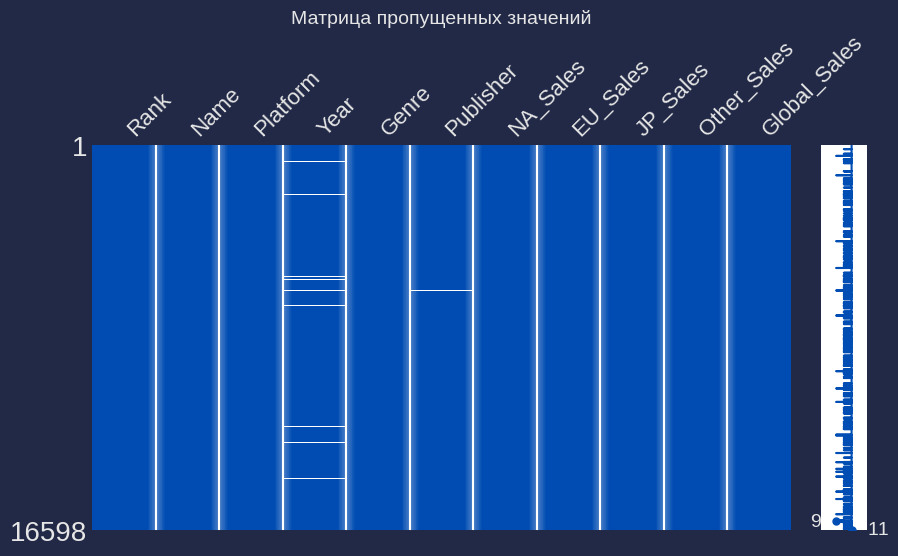

In [29]:
#наличие пропусков
data.isna().sum()

# Визуализация недостающих данных
msno.matrix(data, figsize=(10, 5), color=(0, 0.3, 0.7))
plt.title('Матрица пропущенных значений', fontsize=14)
cbpunk.add_glow_effects()
plt.show()

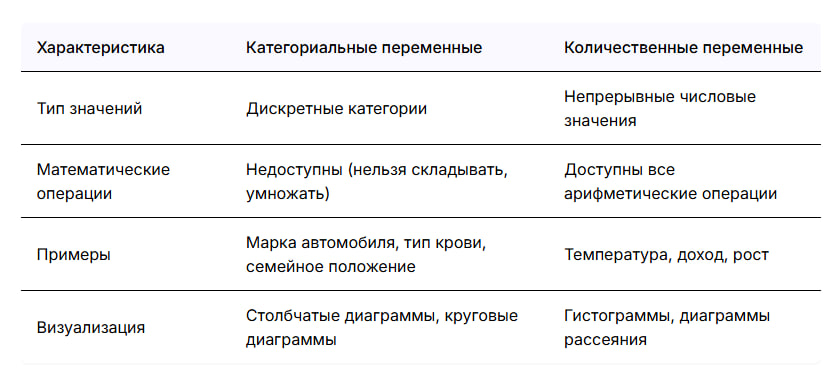

In [30]:

data.head()


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [31]:
# Категориальные столбцы
categorical_columns = data.select_dtypes(include=['object']).columns
print("Категориальные столбцы:", categorical_columns)

Категориальные столбцы: Index(['Name', 'Platform', 'Genre', 'Publisher'], dtype='object')


In [32]:
# Выбор только числовых столбцов для расчета корреляции
numeric_data = data.select_dtypes(include=['float64', 'int64'])

# Вычисление корреляционной матрицы для числовых столбцов
corr = numeric_data.corr()

# Визуализация корреляционной матрицы с помощью градиента
corr.style.background_gradient(cmap='Blues')

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
Rank,1.000000,0.178814,-0.401362,-0.379123,-0.267785,-0.332986,-0.427407
Year,0.178814,1.000000,-0.091402,0.006014,-0.169316,0.041058,-0.074735
NA_Sales,-0.401362,-0.091402,1.000000,0.767727,0.449787,0.634737,0.941047
EU_Sales,-0.379123,0.006014,0.767727,1.000000,0.435584,0.726385,0.902836
JP_Sales,-0.267785,-0.169316,0.449787,0.435584,1.000000,0.290186,0.611816
Other_Sales,-0.332986,0.041058,0.634737,0.726385,0.290186,1.000000,0.748331
Global_Sales,-0.427407,-0.074735,0.941047,0.902836,0.611816,0.748331,1.000000


# Визуализация

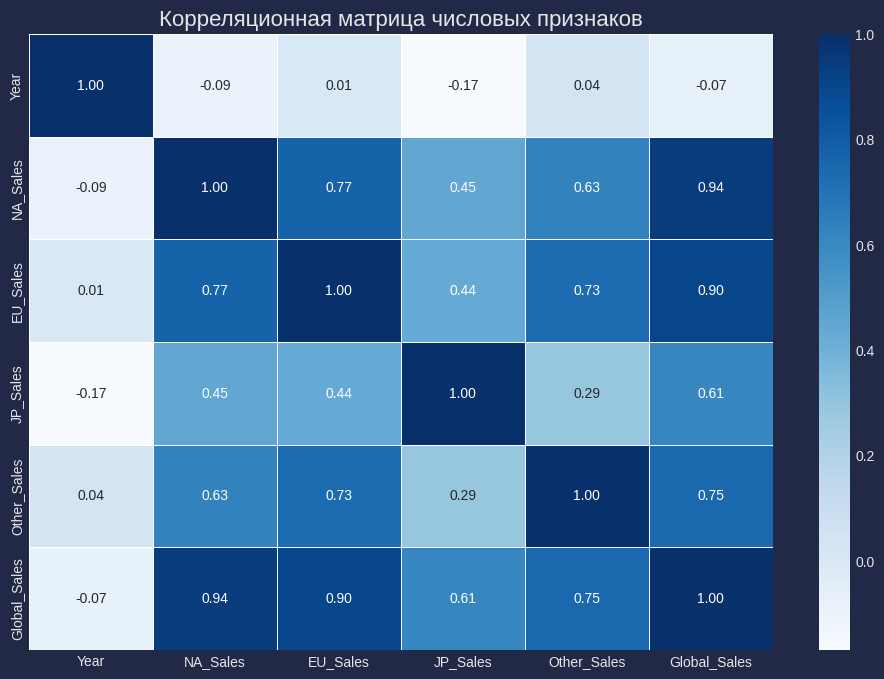

In [33]:
# 2. Корреляционный анализ (только числовые признаки)
numerical_cols = ['Year', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
data_clean = data.dropna(subset=numerical_cols)  # Удаляем пропуски в числовых столбцах

# Расчет корреляционной матрицы
corr_matrix = data_clean[numerical_cols].corr()

# Визуализация корреляционной матрицы
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".2f", linewidths=0.5)
plt.title('Корреляционная матрица числовых признаков', fontsize=16)
cbpunk.add_glow_effects()
plt.show()

In [34]:
# Топ-10 издателей по количеству игр
print("Топ-10 издателей по количеству игр:")
print(data['Publisher'].value_counts().head(10))

# Топ-10 самых продаваемых игр
print("\nТоп-10 самых продаваемых игр по мировым продажам:")
top_games = data[['Name', 'Platform', 'Global_Sales']].sort_values('Global_Sales', ascending=False).head(10)
print(top_games)



Топ-10 издателей по количеству игр:
Publisher
Electronic Arts                 1351
Activision                       975
Namco Bandai Games               932
Ubisoft                          921
Konami Digital Entertainment     832
THQ                              715
Nintendo                         703
Sony Computer Entertainment      683
Sega                             639
Take-Two Interactive             413
Name: count, dtype: int64

Топ-10 самых продаваемых игр по мировым продажам:
                        Name Platform  Global_Sales
0                 Wii Sports      Wii         82.74
1          Super Mario Bros.      NES         40.24
2             Mario Kart Wii      Wii         35.82
3          Wii Sports Resort      Wii         33.00
4   Pokemon Red/Pokemon Blue       GB         31.37
5                     Tetris       GB         30.26
6      New Super Mario Bros.       DS         30.01
7                   Wii Play      Wii         29.02
8  New Super Mario Bros. Wii      Wii  

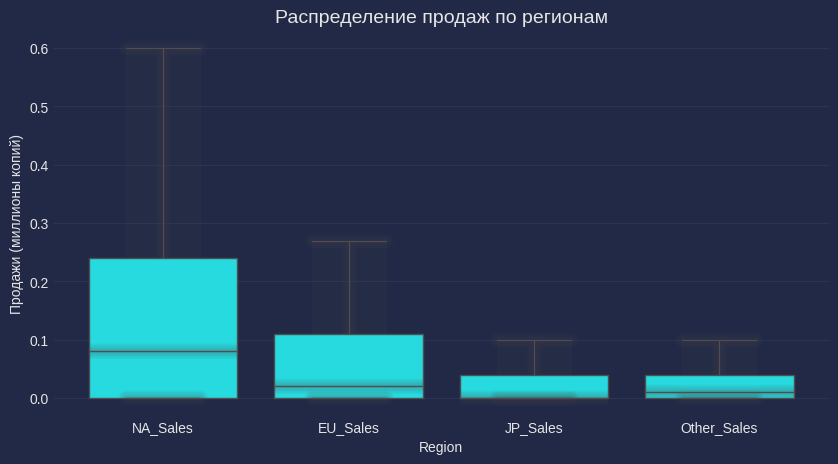

In [35]:

#2: Сравнение продаж по регионам
plt.figure(figsize=(10, 5))
sales_regions = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
data_melt = data_clean.melt(value_vars=sales_regions, var_name='Region', value_name='Sales')
sns.boxplot(x='Region', y='Sales', data=data_melt, showfliers=False)
plt.title('Распределение продаж по регионам', fontsize=14)
plt.ylabel('Продажи (миллионы копий)')
#plt.yscale('log')  # Логарифмическая шкала для лучшей видимости
cbpunk.add_glow_effects()
plt.show()

Выводы: На графике видно, что регион Северная Америка занимает лидирующее место по продажам видеоигр, в то время как Европа занмиает второе место, Япония третее.

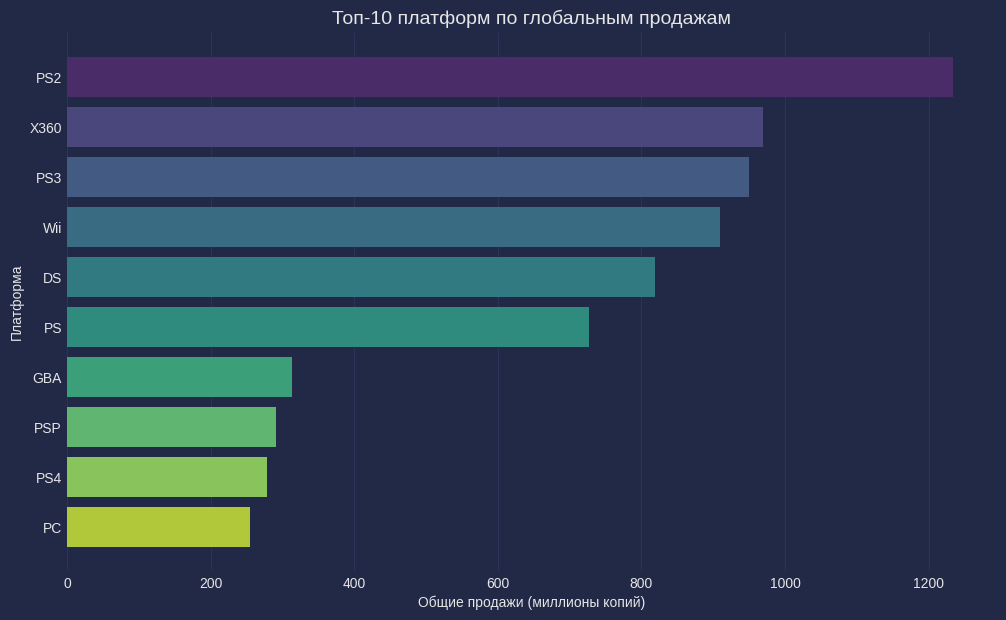

In [36]:
#3: Топ-10 платформ по глобальным продажам
top_platforms = data_clean.groupby('Platform')['Global_Sales'].sum().nlargest(10)
plt.figure(figsize=(12, 7))
sns.barplot(x=top_platforms.values, y=top_platforms.index, palette='viridis')
plt.title('Топ-10 платформ по глобальным продажам', fontsize=14)
plt.xlabel('Общие продажи (миллионы копий)')
plt.ylabel('Платформа')
cbpunk.add_glow_effects()
plt.show()

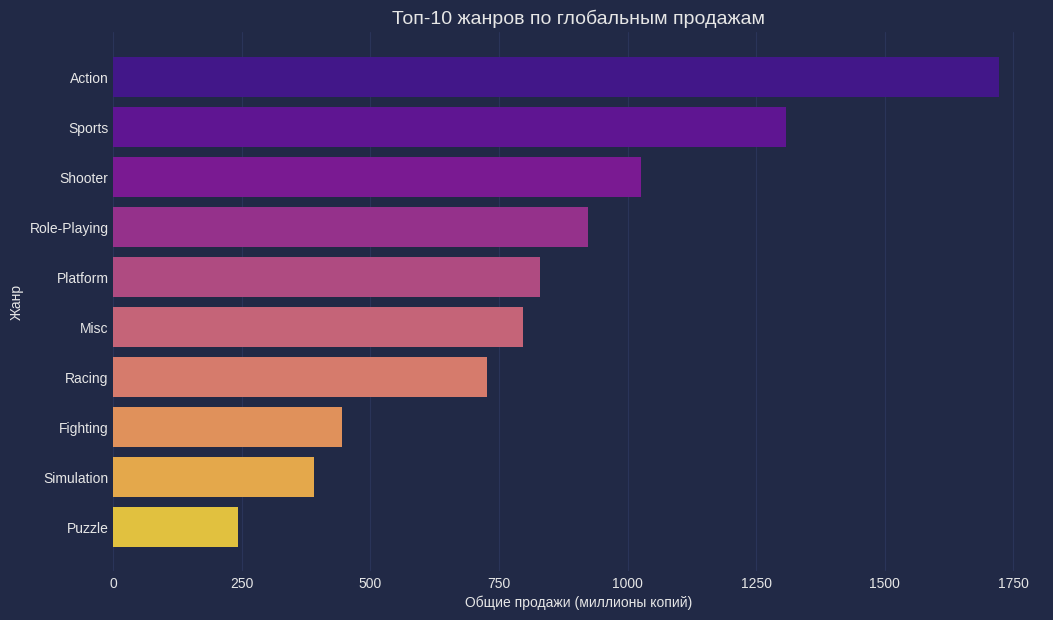

In [37]:
#4: Топ-10 жанров по глобальным продажам
top_genres = data_clean.groupby('Genre')['Global_Sales'].sum().nlargest(10)
plt.figure(figsize=(12, 7))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='plasma')
plt.title('Топ-10 жанров по глобальным продажам', fontsize=14)
plt.xlabel('Общие продажи (миллионы копий)')
plt.ylabel('Жанр')
cbpunk.make_lines_glow()
plt.show()

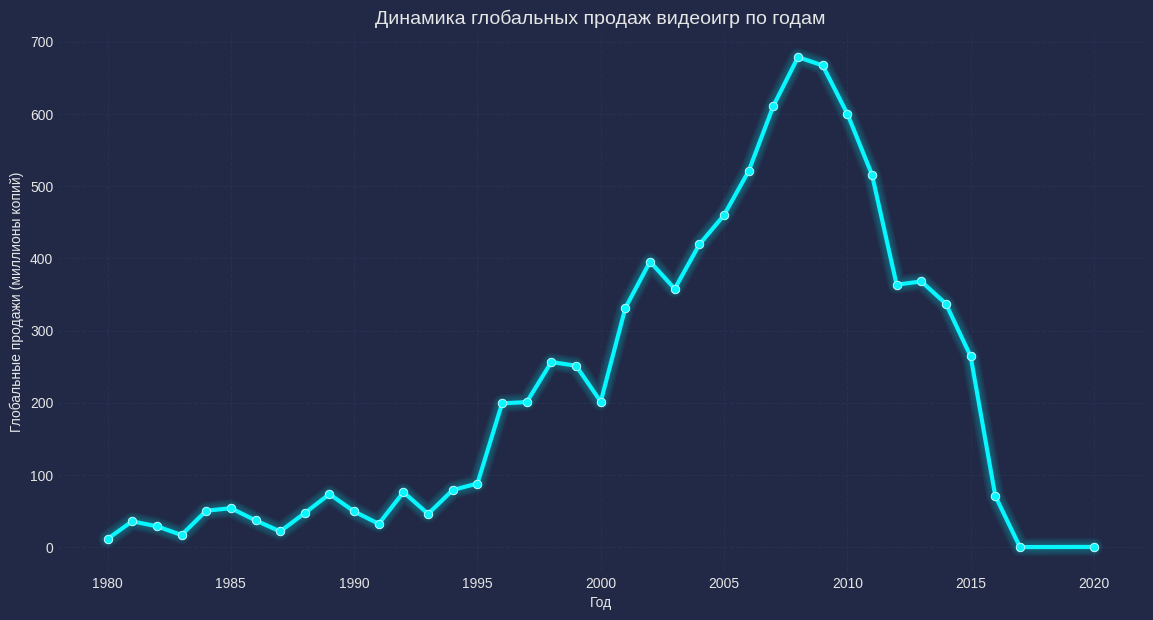

In [38]:
#5: Динамика глобальных продаж по годам
yearly_sales = data_clean.groupby('Year')['Global_Sales'].sum()
plt.figure(figsize=(14, 7))
sns.lineplot(x=yearly_sales.index, y=yearly_sales.values, marker='o', linewidth=3)
plt.title('Динамика глобальных продаж видеоигр по годам', fontsize=14)
plt.xlabel('Год')
plt.ylabel('Глобальные продажи (миллионы копий)')
plt.xticks(range(1980, 2021, 5))
plt.grid(True, linestyle='--', alpha=0.7)
cbpunk.make_lines_glow()
plt.show()

# Выводы:


*   Видна сильная корреляция между продажами в разных регионах и глобальными продажами
* Слабая корреляция между годом выпуска и продажами
* Наиболее популярными жанрами во всем мире являются: экшены, спортивные игры и шутеры.
* Наиболее популярными платформами: PS2, X360, PS3

